In [22]:
import os
import ROOT
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt

# Enable interactive JSROOT graphics in Jupyter
%jsroot off

In [23]:

file_path = "/home/mats/projects/geant4/pMultiStepPGGenerator/data/PhaseSpace_WaterCa0.root"
# load root file
file = ROOT.TFile(file_path)
file.ls()  # List the contents of the file to find the tree name

tree_name = "PhaseSpace"

# # Initialize RDataFrame
rdf = ROOT.RDataFrame(tree_name, file_path)

TFile**		/home/mats/projects/geant4/pMultiStepPGGenerator/data/PhaseSpace_WaterCa0.root	
 TFile*		/home/mats/projects/geant4/pMultiStepPGGenerator/data/PhaseSpace_WaterCa0.root	
  KEY: TTree	PhaseSpace;1	Scored Particles on Outer Cylinder


In [24]:
column_string = ""
for col in rdf.GetColumnNames():
    column_string += col + ", "
print(column_string)

creation_energy_MeV, creation_process, energy_MeV, eventid, interaction_id, mom_dir_x, mom_dir_y, mom_dir_z, pdg, pos_x_cm, pos_y_cm, pos_z_cm, target_A, target_Z, time_ns, 


In [25]:
column_names = rdf.GetColumnNames()
rdf = rdf.Define("process_clean", "std::string(creation_process.data())")

# Extract only the necessary columns for frequency counting
columns_to_extract = ["pdg", "process_clean"] if "creation_process" in column_names else ["pdg"]
data = rdf.AsNumpy(columns_to_extract)

# 5. Distributions (Replicating Pandas value_counts)
print("\n--- Particle Type (PDG) Distribution ---")
pdg_counts = Counter(data["pdg"])
for pdg, count in pdg_counts.most_common():
    print(f"{pdg:<10} : {count}")



--- Particle Type (PDG) Distribution ---
22         : 1715
2112       : 536
2212       : 41


In [26]:
data.keys()

dict_keys(['pdg', 'process_clean'])

In [27]:

print("\n--- Creation Process Distribution ---")
process_counts = Counter(data["process_clean"])
for proc, count in process_counts.most_common():
    # Ensure the output is formatted as a standard Python string
    proc_str = proc.decode('utf-8') if isinstance(proc, bytes) else str(proc)
    print(f"{proc_str:<15} : {count}")


--- Creation Process Distribution ---
protonInelastic : 1684
annihil         : 570
neutronInelastic : 14
RadioactiveDecay : 11
Primary         : 5
eBrem           : 5
hadElastic      : 3


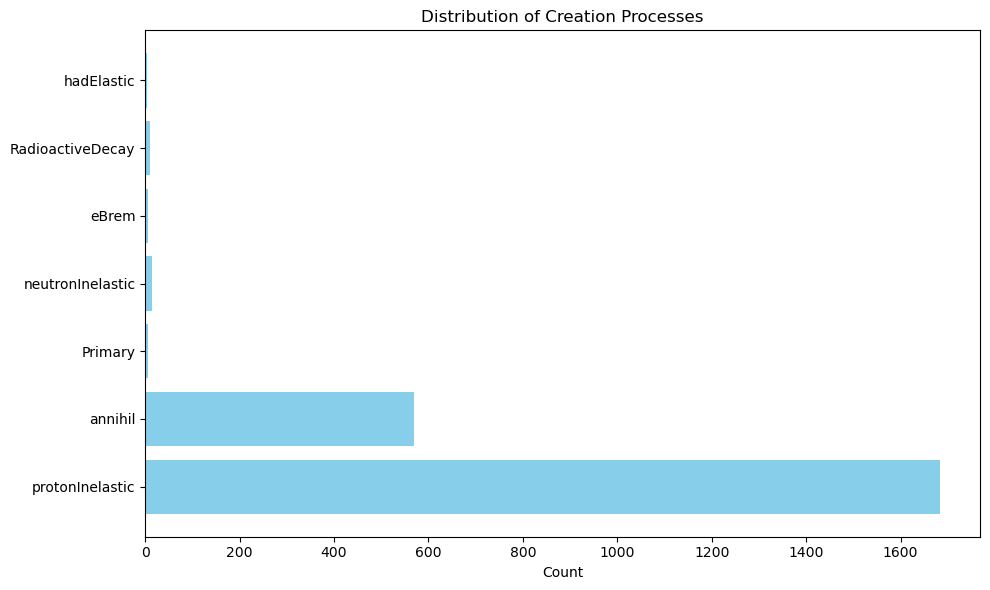

In [28]:
# create plot with the processes
plt.figure(figsize=(10, 6))
process_names = [proc.decode('utf-8') if isinstance(proc, bytes) else str(proc) for proc in process_counts.keys()]
process_values = list(process_counts.values())
plt.barh(process_names, process_values, color='skyblue')
plt.xlabel('Count')
plt.title('Distribution of Creation Processes')
plt.tight_layout()
plt.show()

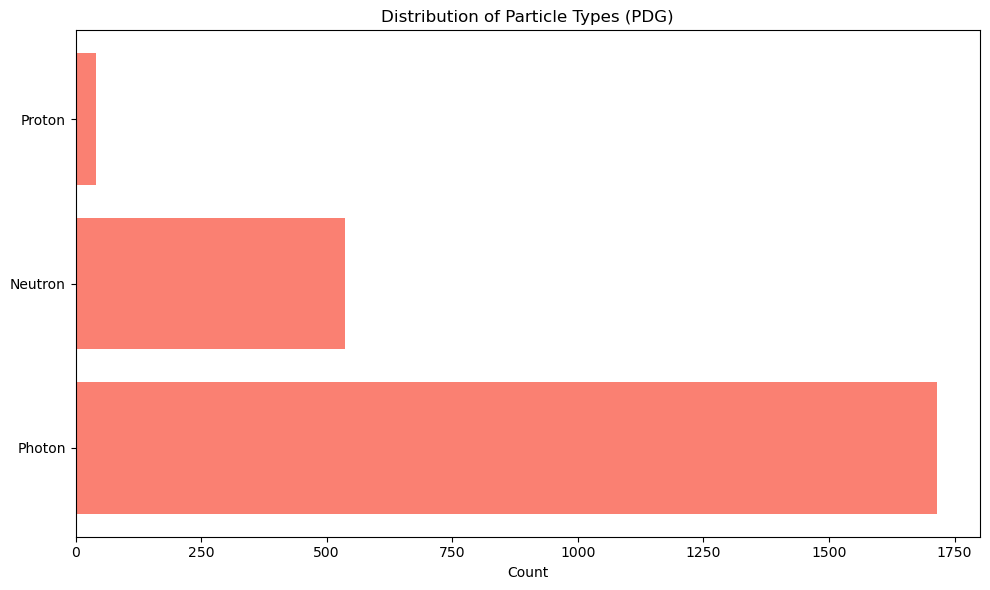

In [29]:
# create plot of pdg
pdg_to_name = {
    22: "Photon", 2212: "Proton", 11: "Electron", -11: "Positron", 2112: "Neutron", 1000010020: "Deuteron",}
plt.figure(figsize=(10, 6))
pdg_names = [str(pdg) for pdg in pdg_counts.keys()]
pdg_names = [pdg_to_name.get(int(pdg), str(pdg)) for pdg in pdg_names]
pdg_values = list(pdg_counts.values())
plt.barh(pdg_names, pdg_values, color='salmon')
plt.xlabel('Count')
plt.title('Distribution of Particle Types (PDG)')
plt.tight_layout()
plt.show()

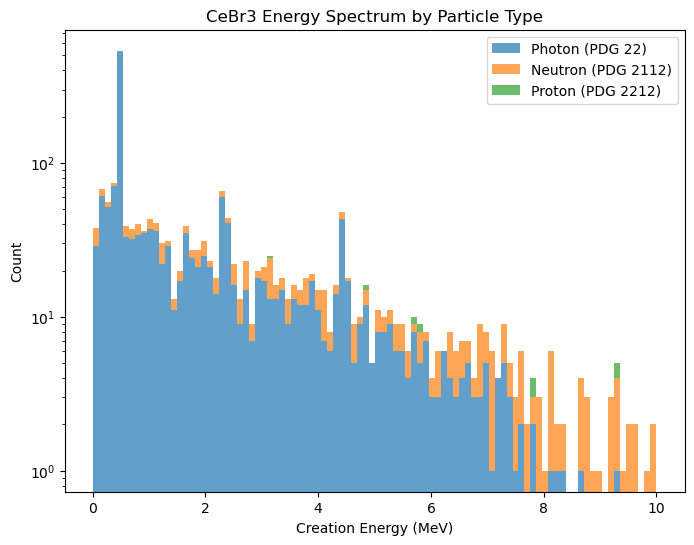

In [ ]:
# Creation energy spectrum particle specific
fig, ax = plt.subplots(figsize=(8, 6))
rdf_data = rdf.AsNumpy(["pdg", "energy_MeV"])
pdg_values = rdf_data["pdg"]
energy_MeV = rdf_data["energy_MeV"]

# Collect data arrays and labels into lists
data_to_plot = []
labels = []
unique_pdgs = sorted(set(pdg_values))

for pdg in unique_pdgs:
    mask = pdg_values == pdg
    data_to_plot.append(energy_MeV[mask])
    pdg_name = pdg_to_name.get(int(pdg), str(pdg))
    labels.append(f"{pdg_name} (PDG {pdg})")
bin_size = 0.01  # MeV
n_bins = int((energy_MeV.max() - energy_MeV.min()) / (bin_size ))
val_range = (0, 10)  # Adjust as needed for your energy range
# Plot stacked histogram
ax.hist(
    data_to_plot,
    bins=n_bins,
    range=val_range,
    stacked=True,
    alpha=0.7,
    label=labels
)

ax.set_title("CeBr3 Energy Spectrum by Particle Type")
ax.set_xlabel("Creation Energy (MeV)")
ax.set_ylabel("Count")
ax.set_yscale('log')
ax.legend()
plt.show()

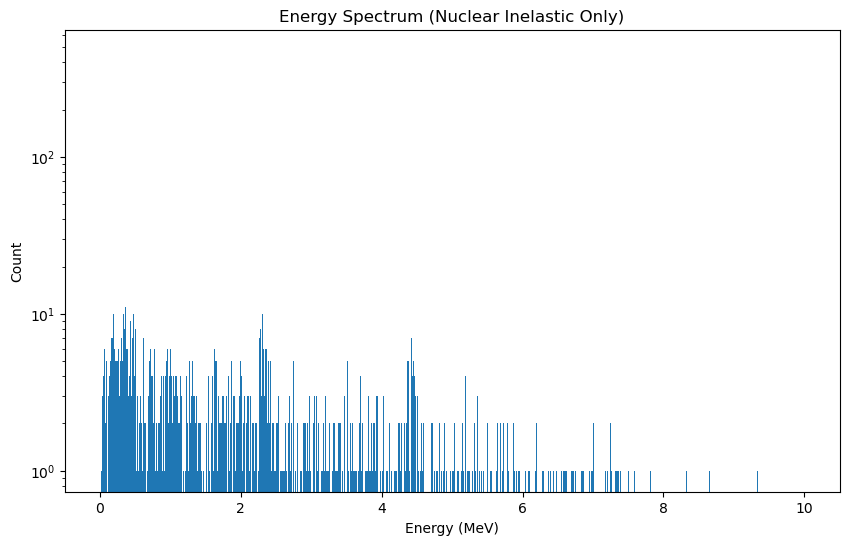

In [36]:
# Assuming the raw branch name for the particle's energy at creation is 'initial_energy'
# Update 'initial_energy' if your ROOT file uses a different branch name
e_min, e_max = 0.0, 10.0
bin_width = 0.01 
n_bins = int((e_max - e_min) / bin_width)
fig, ax = plt.subplots(figsize=(10, 6))

# Use the 'process_clean' logic to filter, but pull the raw 'initial_energy'
# Adding a filter for > 0 to exclude the -1 placeholder values effectively
rdf_filtered = rdf.Filter('pdg == 22')
raw_energies = rdf_filtered.AsNumpy(["energy_MeV"])["energy_MeV"]

ax.hist(raw_energies, bins=n_bins, range=(e_min, e_max))
ax.set_title("Energy Spectrum (Nuclear Inelastic Only)")
ax.set_xlabel("Energy (MeV)")
ax.set_ylabel("Count")
ax.set_yscale('log')
plt.show()